# K Means Clustering Algorithm Implementation

In [100]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
import pandas as pd
import numpy as np

In [148]:
x, y = make_blobs(n_samples=1000,centers=3,n_features=2,random_state=23)

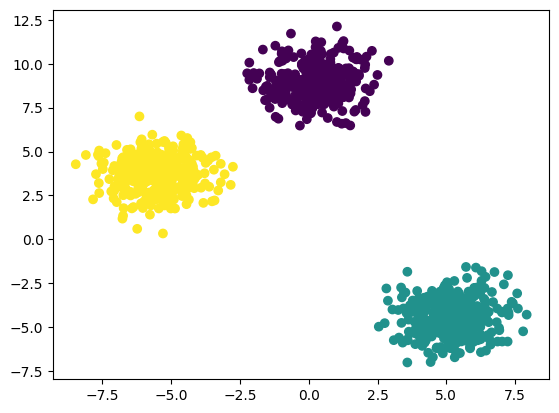

In [149]:
plt.scatter(x[:,0],x[:,1],c=y)

In [150]:
from sklearn.model_selection import train_test_split
x_train, x_test , y_train, y_test = train_test_split(x,y,test_size=0.33,random_state=42)

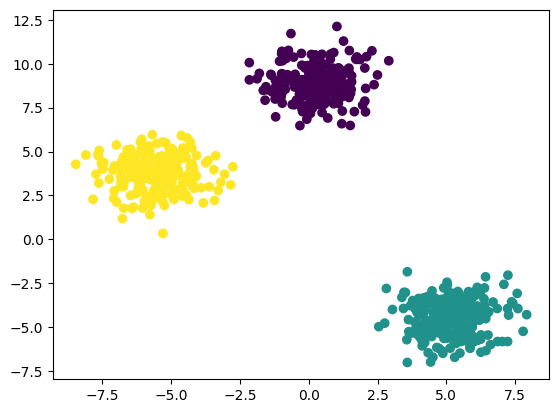

In [151]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_train)

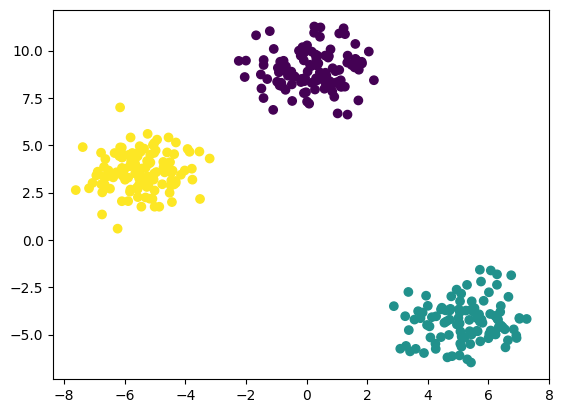

In [152]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_test)

In [153]:
from sklearn.cluster import KMeans

In [154]:
## manual process
## elbow method to select the k value

wcss = []
for k in range(1,100):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

In [155]:
wcss

[34827.57682552021,
 7935.4372861454185,
 1319.2730531585605,
 1171.5031490581139,
 1071.8957738433837,
 866.4433782572448,
 773.1138259202514,
 687.8028472424064,
 582.7353938427458,
 598.3160664028859,
 515.598346069097,
 463.4610517926487,
 451.39966506495404,
 405.60230762278894,
 416.6445512540075,
 365.28889330070274,
 338.3482649767369,
 330.28604430183003,
 294.49697396545326,
 286.4820824488894,
 268.91419881944034,
 264.978461862077,
 253.0897720285075,
 232.14384022602482,
 233.10544906900947,
 231.81840879008527,
 220.10852915643898,
 209.89804989333294,
 197.91424061214155,
 191.3317875250395,
 191.223240380355,
 185.02783761201226,
 174.30277120663186,
 168.69635049311594,
 159.0090999188018,
 163.88553817379278,
 154.52765581253317,
 147.9474898260852,
 147.51888959914183,
 141.06156955208928,
 135.84858448625536,
 135.91173290268688,
 127.47936094156032,
 122.23675583839699,
 128.20275014940466,
 119.94323046317149,
 107.81711145007762,
 116.6758601994546,
 112.78085106

Text(0, 0.5, 'intertia')

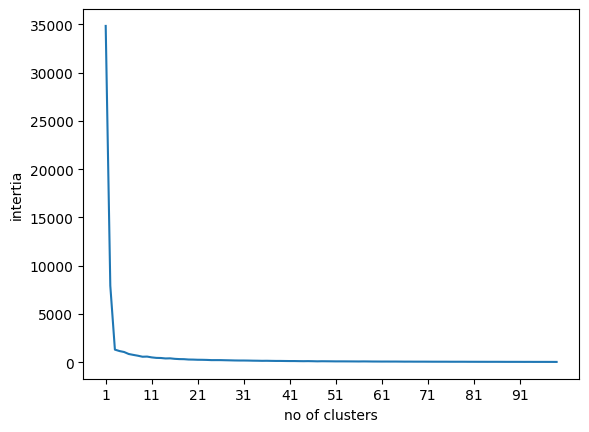

In [156]:
plt.plot(range(1,100),wcss)
plt.xticks(range(1,100,10))
plt.xlabel("no of clusters")
plt.ylabel("intertia")

In [157]:
kmeans = KMeans(n_clusters=3,init="k-means++")

In [158]:
y_labels = kmeans.fit_predict(x_train)

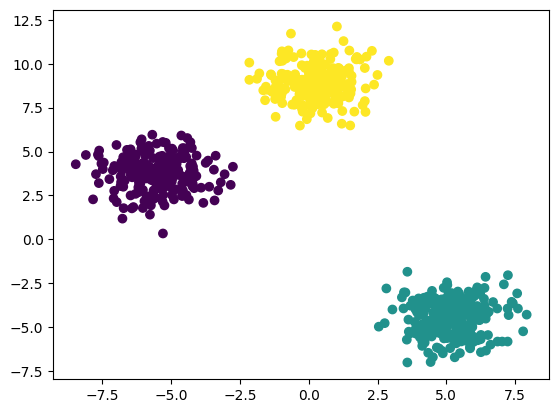

In [159]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_labels)

In [160]:
y_test_labels = kmeans.predict(x_test)

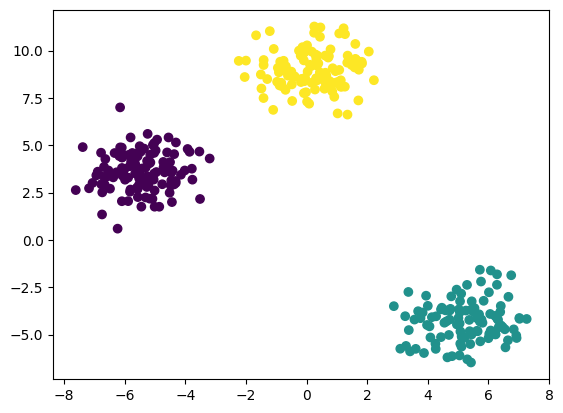

In [161]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_test_labels)

In [162]:
## automation with finding elbow or k value
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [163]:
from kneed import KneeLocator

In [164]:
kl = KneeLocator(range(1,100),wcss,curve="convex",direction="decreasing")

In [165]:
kl.elbow

np.int64(3)

In [166]:
## performace matrix

from sklearn.metrics import silhouette_score

In [167]:
silhouette_coeff = []

In [168]:
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train)
    silhouette_coeff.append(silhouette_score(x_train,kmeans.labels_))


In [169]:
silhouette_coeff

[0.7281443868598331,
 0.8071181203797672,
 0.6419605021469034,
 0.5054333080575093,
 0.475072597890326,
 0.33910884527822077,
 0.3427542763753242,
 0.33807088409350516,
 0.3343202116701764]

Text(0, 0.5, 'score')

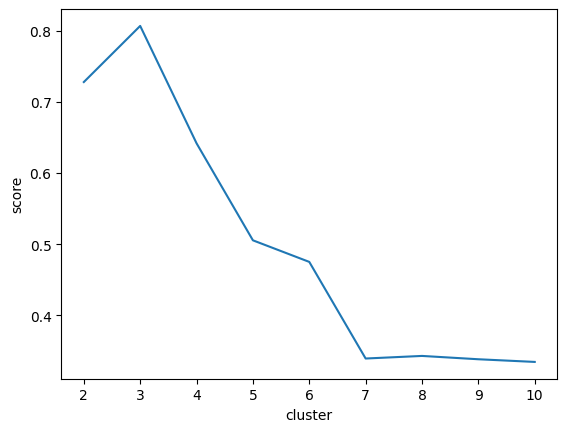

In [170]:
plt.plot(range(2,11),silhouette_coeff)
plt.xlabel("cluster")
plt.ylabel("score")